# Notebook 06 — Model Comparison (SOH)

## Objective
Answer: **how does the proposed AHRF (v1) compare with standard regression, tree, ensemble, and boosting baselines for SOH prediction?** Six models, one identical leakage-safe protocol, one untouched chronological test set.

## Scope
Exactly 6 models: Linear Regression, Polynomial Regression (degree 2), Decision Tree, Random Forest, Gradient Boosting, AHRF-v1 (proposed). No AHRF-v2 (that ablation lives in Notebook 05, which is not reopened here), no XGBoost/LightGBM/CatBoost.

## Workflow Position
```
01-04 (LOCKED) -> 05 (LOCKED, AHRF-v1 proposed / AHRF-v2 ablation) -> [YOU ARE HERE] 06 Model Comparison
-> 07 Explainability (SHAP) -> 08 Decision Engine & Summary
```


## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.core.config import FEATURE_DATA, RESULTS
from src.hybrid_model.weighted_random_forest import AdaptiveWeightedRF

plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42
PRIMARY_METRIC = "MAE"


In [3]:
df = pd.read_csv(FEATURE_DATA / "full_labeled_dataset.csv").sort_values("cycle_index").reset_index(drop=True)
print("Loaded dataset:", df.shape)


Loaded dataset: (168, 85)


## 2. Feature Definition — CRITICAL FIX 1 (Target Leakage)

Built once, as a global exclusion of every target/identifier/auxiliary column -- not a per-target exclusion that accidentally leaves `SOH (%)` itself (or the other targets) inside X.


In [4]:
NON_FEATURE_COLUMNS = [
    "SOH (%)", "SOC", "RUL", "Capacity",
    "File", "cycle_index", "Experiment", "battery_id", "filename",
    "type", "start_time", "test_id", "uid", "Re", "Rct", "ambient_temperature",
]

MODEL_CANDIDATE_FEATURE_COLUMNS = [c for c in df.columns if c not in NON_FEATURE_COLUMNS]

TARGET_COL = "SOH (%)"

X = df[MODEL_CANDIDATE_FEATURE_COLUMNS].copy()
y = df[TARGET_COL].copy()

assert TARGET_COL not in X.columns, "LEAKAGE: target column present in X"
assert "SOC" not in X.columns, "LEAKAGE: SOC present in X"
assert "RUL" not in X.columns, "LEAKAGE: RUL present in X"
assert "Capacity" not in X.columns, "LEAKAGE: Capacity present in X"
assert len(X) == len(y), "X/y length mismatch"

print(f"Model candidate feature count: {len(MODEL_CANDIDATE_FEATURE_COLUMNS)}")
print(f"X shape: {X.shape}   y shape: {y.shape}")
print("PASS: no target/auxiliary leakage in X (hard assertions).")


Model candidate feature count: 77
X shape: (168, 77)   y shape: (168,)
PASS: no target/auxiliary leakage in X (hard assertions).


## 3. Chronological Split + Training-Only Imputation — CRITICAL FIX 2 (Same as Notebook 05)


In [5]:
n = len(df)
split = int(n * 0.8)

train_df = df.iloc[:split].copy()
test_df = df.iloc[split:].copy()

X_train_raw, y_train = X.iloc[:split].copy(), y.iloc[:split].copy()
X_test_raw, y_test = X.iloc[split:].copy(), y.iloc[split:].copy()

assert train_df["cycle_index"].max() < test_df["cycle_index"].min(), (
    "CHRONOLOGY VIOLATED: train cycles overlap with or exceed test cycles."
)
assert len(train_df) + len(test_df) == len(df), "ROW COUNT MISMATCH after split."

train_min, train_max = int(train_df["cycle_index"].min()), int(train_df["cycle_index"].max())
test_min, test_max = int(test_df["cycle_index"].min()), int(test_df["cycle_index"].max())
print(f"Train rows: {len(X_train_raw)}  Test rows: {len(X_test_raw)}  "
      f"(train cycles {train_min}-{train_max}, test cycles {test_min}-{test_max})")


Train rows: 134  Test rows: 34  (train cycles 1-134, test cycles 135-168)


In [6]:
nan_in_train = int(X_train_raw.isna().sum().sum())
nan_in_test = int(X_test_raw.isna().sum().sum())
affected_features = X_train_raw.columns[X_train_raw.isna().any()].tolist()
print(f"NaN count in X_train: {nan_in_train}   NaN count in X_test: {nan_in_test}")
print(f"Affected features: {affected_features}")

imputer = SimpleImputer(strategy="median")
imputer.fit(X_train_raw)  # fit ONLY on training data -- test rows untouched during preprocessing

X_train = pd.DataFrame(imputer.transform(X_train_raw), columns=X_train_raw.columns, index=X_train_raw.index)
X_test = pd.DataFrame(imputer.transform(X_test_raw), columns=X_test_raw.columns, index=X_test_raw.index)

assert X_train.isna().sum().sum() == 0, "NaNs remain in X_train after imputation"
assert X_test.isna().sum().sum() == 0, "NaNs remain in X_test after imputation"
assert np.isfinite(X_train.to_numpy()).all(), "Non-finite values in X_train after imputation"
assert np.isfinite(X_test.to_numpy()).all(), "Non-finite values in X_test after imputation"
# The imputer's own learned statistics must reflect X_train's medians, not X_test's or the full df's
assert np.allclose(imputer.statistics_, X_train_raw.median(numeric_only=True).reindex(X_train_raw.columns).to_numpy(), equal_nan=True), (
    "Imputer statistics do not match X_train's own medians -- possible fit-on-wrong-data bug."
)

print("PASS: zero NaN, zero inf after imputation; imputer fitted on X_train ONLY (verified against X_train's own medians).")


NaN count in X_train: 78   NaN count in X_test: 0
Affected features: ['Re_nearest', 'Rct_nearest', 'Re_trend', 'Rct_trend']
PASS: zero NaN, zero inf after imputation; imputer fitted on X_train ONLY (verified against X_train's own medians).


## 4. Model Configuration — CRITICAL FIX 3 (Fair Tuning)

**RF and AHRF-v1 hyperparameters are reused from Notebook 05's actual executed SOH tuning run** (`tune_random_forest()`/`tune_weighted_rf()`, both `TimeSeriesSplit`-based, `n_trials=15`, `cv=3`) -- not re-tuned here, and not left at arbitrary defaults while AHRF gets special treatment. Linear Regression, Polynomial Regression, Decision Tree, and Gradient Boosting all use simple, fixed, documented configurations -- consistently untuned, so no baseline is quietly disadvantaged relative to another.

**Values below are copied directly from Notebook 05's saved `notebook05_run_metadata.pkl` (`best_params["SOH"]`), produced by that notebook's actual execution** -- not guessed or re-derived here.


In [7]:
# Reused from Notebook 05's actual executed SOH tuning (TimeSeriesSplit Optuna, n_trials=15, cv=3).
# Source: notebook05_run_metadata.pkl -> best_params["SOH"]["rf"] / ["ahrf"]
BEST_RF_PARAMS = {
    "n_estimators": 300, "max_depth": 4, "min_samples_split": 8,
    "min_samples_leaf": 2, "max_features": None,
}
BEST_AHRF_PARAMS = {
    "n_estimators": 100, "max_depth": 18, "min_samples_split": 5,
    "min_samples_leaf": 1, "max_features": None, "weight_power": 3.379262681875024,
}

# Fixed, documented configurations for the untuned baselines -- same reasoning applied
# to every one of them, not selectively tuned.
DECISION_TREE_PARAMS = {"max_depth": 8, "random_state": RANDOM_STATE}
GRADIENT_BOOSTING_PARAMS = {"n_estimators": 200, "random_state": RANDOM_STATE}

print("Tuning strategy summary:")
print(f"  Random Forest : reused from Notebook 05 (TimeSeriesSplit Optuna, n_trials=15, cv=3) -> {BEST_RF_PARAMS}")
print(f"  AHRF-v1       : reused from Notebook 05 (TimeSeriesSplit Optuna, n_trials=15, cv=3) -> {BEST_AHRF_PARAMS}")
print(f"  Decision Tree : fixed, documented, untuned -> {DECISION_TREE_PARAMS}")
print(f"  Gradient Boosting : fixed, documented, untuned -> {GRADIENT_BOOSTING_PARAMS}")
print("  Linear Regression : no hyperparameters")
print("  Polynomial Regression (degree 2) : no hyperparameters beyond the fixed degree")


Tuning strategy summary:
  Random Forest : reused from Notebook 05 (TimeSeriesSplit Optuna, n_trials=15, cv=3) -> {'n_estimators': 300, 'max_depth': 4, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': None}
  AHRF-v1       : reused from Notebook 05 (TimeSeriesSplit Optuna, n_trials=15, cv=3) -> {'n_estimators': 100, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'weight_power': 3.379262681875024}
  Decision Tree : fixed, documented, untuned -> {'max_depth': 8, 'random_state': 42}
  Gradient Boosting : fixed, documented, untuned -> {'n_estimators': 200, 'random_state': 42}
  Linear Regression : no hyperparameters
  Polynomial Regression (degree 2) : no hyperparameters beyond the fixed degree


## 5. Train All 6 Models — Identical X_train/y_train, Identical X_test/y_test


In [8]:
results = {}

def evaluate_and_store(name, model, X_tr, y_tr, X_te, y_te):
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    training_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = model.predict(X_te)
    prediction_time = time.perf_counter() - t0

    assert np.isfinite(y_pred).all(), f"{name}: predictions contain non-finite values"

    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)

    assert np.isfinite([mae, rmse, r2]).all(), f"{name}: a metric is non-finite"

    results[name] = {
        "MAE": mae, "RMSE": rmse, "R2": r2,
        "Training_Time": training_time, "Prediction_Time": prediction_time,
        "y_pred": y_pred, "model": model,
    }
    print(f"{name:24s} MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}  "
          f"train={training_time:.3f}s  pred={prediction_time:.4f}s")
    return model


In [9]:
# 1. Linear Regression -- simplest possible baseline
evaluate_and_store("Linear Regression", LinearRegression(), X_train, y_train, X_test, y_test)


Linear Regression        MAE=2.5266  RMSE=2.6406  R2=-4.6535  train=0.017s  pred=0.0011s


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](77,)","[ 0.,-0.,-0.,...,-0., 0., 0.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](77,)","['Voltage_measured_mean','Voltage_measured_std','Voltage_measured_var',..., 'Rct_nearest','Re_trend','Rct_trend']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,61.49
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,77
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [10]:
# 2. Polynomial Regression (degree 2)
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
evaluate_and_store("Polynomial Regression", poly_model, X_train, y_train, X_test, y_test)


Polynomial Regression    MAE=4.5302  RMSE=4.6351  R2=-16.4188  train=0.043s  pred=0.0022s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](77,)","['Voltage_measured_mean','Voltage_measured_std','Voltage_measured_var',..., 'Rct_nearest','Re_trend','Rct_trend']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,77
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [11]:
# 3. Decision Tree -- fixed, documented configuration (see Section 4)
evaluate_and_store("Decision Tree", DecisionTreeRegressor(**DECISION_TREE_PARAMS), X_train, y_train, X_test, y_test)


Decision Tree            MAE=2.1898  RMSE=2.4743  R2=-3.9638  train=0.004s  pred=0.0013s


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [12]:
# 4. Random Forest -- Notebook 05's tuned hyperparameters (see Section 4)
rf_model = RandomForestRegressor(**BEST_RF_PARAMS, random_state=RANDOM_STATE, n_jobs=-1)
evaluate_and_store("Random Forest", rf_model, X_train, y_train, X_test, y_test)


Random Forest            MAE=2.7967  RMSE=2.9956  R2=-6.2756  train=0.284s  pred=0.0525s


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max

In [13]:
# 5. Gradient Boosting -- fixed, documented configuration (see Section 4)
evaluate_and_store("Gradient Boosting", GradientBoostingRegressor(**GRADIENT_BOOSTING_PARAMS), X_train, y_train, X_test, y_test)


Gradient Boosting        MAE=2.1062  RMSE=2.3423  R2=-3.4480  train=0.266s  pred=0.0043s


,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [14]:
# 6. AHRF-v1 (proposed) -- Notebook 05's tuned hyperparameters, weighting_method="oob" explicitly.
# This is AHRF-v1, NOT AHRF-v2 (temporal) -- the v1/v2 ablation belongs to Notebook 05 only.
ahrf_model = AdaptiveWeightedRF(**BEST_AHRF_PARAMS, random_state=RANDOM_STATE, weighting_method="oob")
evaluate_and_store("AHRF (proposed)", ahrf_model, X_train, y_train, X_test, y_test)

assert np.isclose(ahrf_model.tree_weights_.sum(), 1.0, atol=1e-6), "AHRF tree weights do not sum to 1"
print()
print("AHRF-v1 configuration:")
print(f"  n_estimators={BEST_AHRF_PARAMS['n_estimators']}  max_depth={BEST_AHRF_PARAMS['max_depth']}  "
      f"min_samples_split={BEST_AHRF_PARAMS['min_samples_split']}  min_samples_leaf={BEST_AHRF_PARAMS['min_samples_leaf']}  "
      f"max_features={BEST_AHRF_PARAMS['max_features']}  weight_power={BEST_AHRF_PARAMS['weight_power']:.4f}")
print(f"  weighting_method={ahrf_model.weighting_method}  (explicitly OOB, not temporal)")
print(f"  sum(tree_weights_) = {ahrf_model.tree_weights_.sum():.8f}  [PASS]")


AHRF (proposed)          MAE=2.4647  RMSE=2.6957  R2=-4.8919  train=0.154s  pred=0.0061s

AHRF-v1 configuration:
  n_estimators=100  max_depth=18  min_samples_split=5  min_samples_leaf=1  max_features=None  weight_power=3.3793
  weighting_method=oob  (explicitly OOB, not temporal)
  sum(tree_weights_) = 1.00000000  [PASS]


## 6. Result Table


In [15]:
comparison_df = pd.DataFrame({
    name: {"MAE": r["MAE"], "RMSE": r["RMSE"], "R2": r["R2"],
           "Training_Time": r["Training_Time"], "Prediction_Time": r["Prediction_Time"]}
    for name, r in results.items()
}).T
comparison_df.index.name = "Model"
comparison_df = comparison_df.reset_index()

comparison_df_sorted = comparison_df.sort_values("MAE", ascending=True).reset_index(drop=True)

print("Full table (original order):")
print(comparison_df.to_string(index=False))
print()
print("Sorted by MAE ascending (summary view):")
print(comparison_df_sorted.to_string(index=False))


Full table (original order):
                Model      MAE     RMSE         R2  Training_Time  Prediction_Time
    Linear Regression 2.526613 2.640640  -4.653522       0.016763         0.001129
Polynomial Regression 4.530233 4.635095 -16.418787       0.043321         0.002155
        Decision Tree 2.189790 2.474326  -3.963800       0.003781         0.001339
        Random Forest 2.796653 2.995593  -6.275557       0.284226         0.052460
    Gradient Boosting 2.106216 2.342256  -3.448046       0.266465         0.004290
      AHRF (proposed) 2.464706 2.695744  -4.891935       0.154414         0.006074

Sorted by MAE ascending (summary view):
                Model      MAE     RMSE         R2  Training_Time  Prediction_Time
    Gradient Boosting 2.106216 2.342256  -3.448046       0.266465         0.004290
        Decision Tree 2.189790 2.474326  -3.963800       0.003781         0.001339
      AHRF (proposed) 2.464706 2.695744  -4.891935       0.154414         0.006074
    Linear Regres

## 7. Visualizations

Neutral coloring throughout -- every model gets the same bar color; AHRF is identified only by a black outline, not a distinct "winning" color, since the outcome should be read from the numbers, not implied visually.


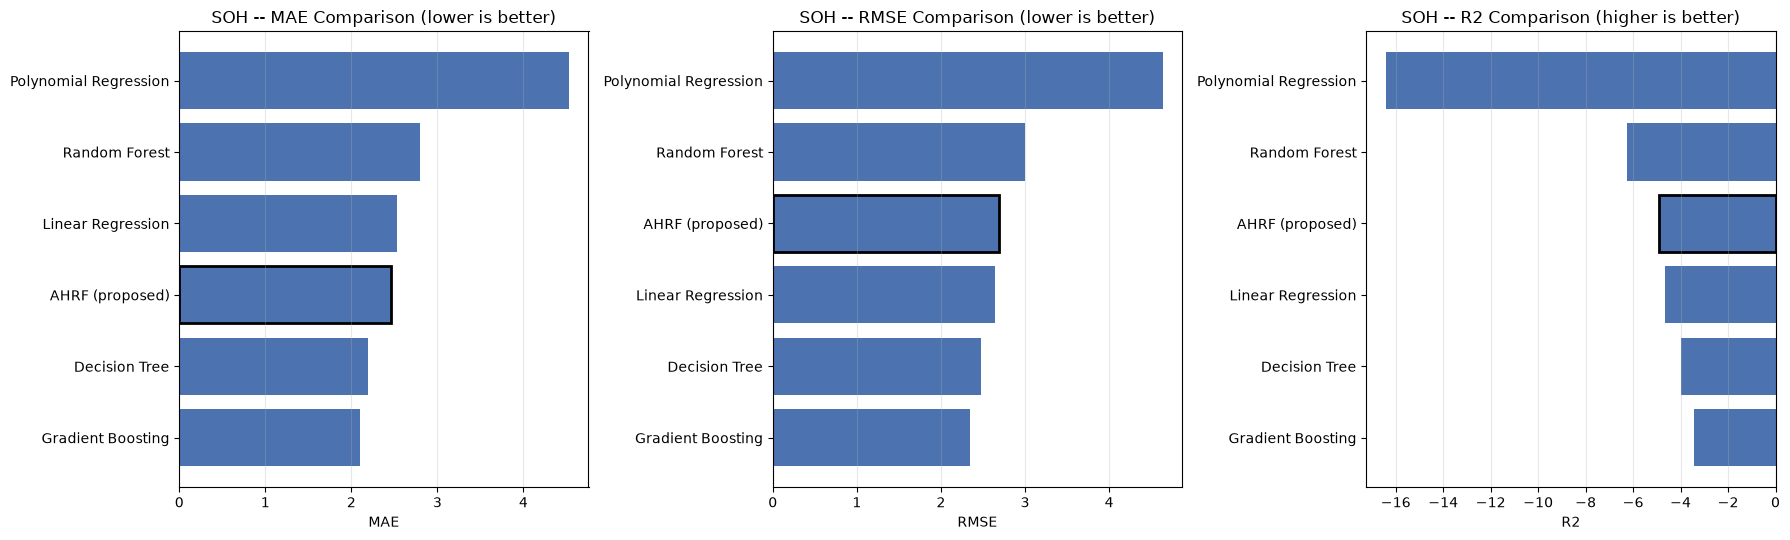

In [16]:
def neutral_bar_colors(model_names, highlight="AHRF (proposed)"):
    return ["#4C72B0" for _ in model_names], ["black" if m == highlight else "none" for m in model_names]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, metric, ascending in [(axes[0], "MAE", True), (axes[1], "RMSE", True), (axes[2], "R2", False)]:
    sub = comparison_df.sort_values(metric, ascending=ascending)
    fill_colors, edge_colors = neutral_bar_colors(sub["Model"])
    ax.barh(sub["Model"], sub[metric], color=fill_colors, edgecolor=edge_colors, linewidth=2)
    ax.set_title(f"SOH -- {metric} Comparison ({'lower' if ascending else 'higher'} is better)")
    ax.set_xlabel(metric)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Learning Curve (Diagnostic Only, TimeSeriesSplit)

Uses `TimeSeriesSplit(n_splits=4)` -- never ordinary `KFold` -- consistent with every other chronological validation in this project. This is diagnostic (over/underfitting behavior vs. training size); its validation scores are NOT used as final test metrics anywhere in this notebook.


PASS: all TimeSeriesSplit learning-curve folds verified chronological.


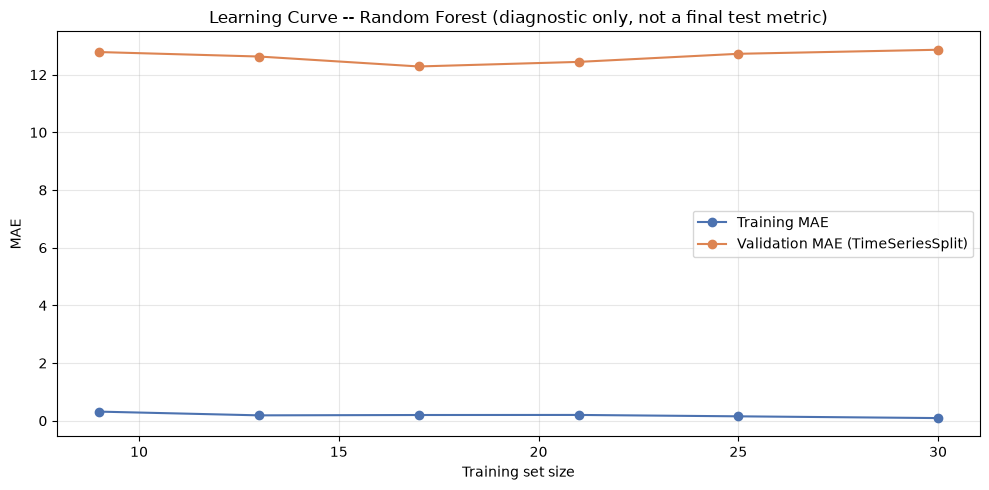

In [17]:
tscv_lc = TimeSeriesSplit(n_splits=4)

# Verify the learning curve's own validation folds are genuinely chronological before using them.
for train_idx, val_idx in tscv_lc.split(X_train):
    assert train_idx.max() < val_idx.min(), "Learning curve fold is NOT chronological -- this should never happen with TimeSeriesSplit."
print("PASS: all TimeSeriesSplit learning-curve folds verified chronological.")

train_sizes = np.linspace(0.3, 1.0, 6)
rf_for_curve = RandomForestRegressor(**BEST_RF_PARAMS, random_state=RANDOM_STATE, n_jobs=-1)

sizes, train_scores, val_scores = learning_curve(
    rf_for_curve, X_train, y_train, train_sizes=train_sizes, cv=tscv_lc,
    scoring="neg_mean_absolute_error", n_jobs=-1,
)

fig, ax = plt.subplots()
ax.plot(sizes, -train_scores.mean(axis=1), label="Training MAE", marker="o", color="#4C72B0")
ax.plot(sizes, -val_scores.mean(axis=1), label="Validation MAE (TimeSeriesSplit)", marker="o", color="#DD8452")
ax.set_title("Learning Curve -- Random Forest (diagnostic only, not a final test metric)")
ax.set_xlabel("Training set size")
ax.set_ylabel("MAE")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Actual vs. Predicted SOH — Best-Performing Model


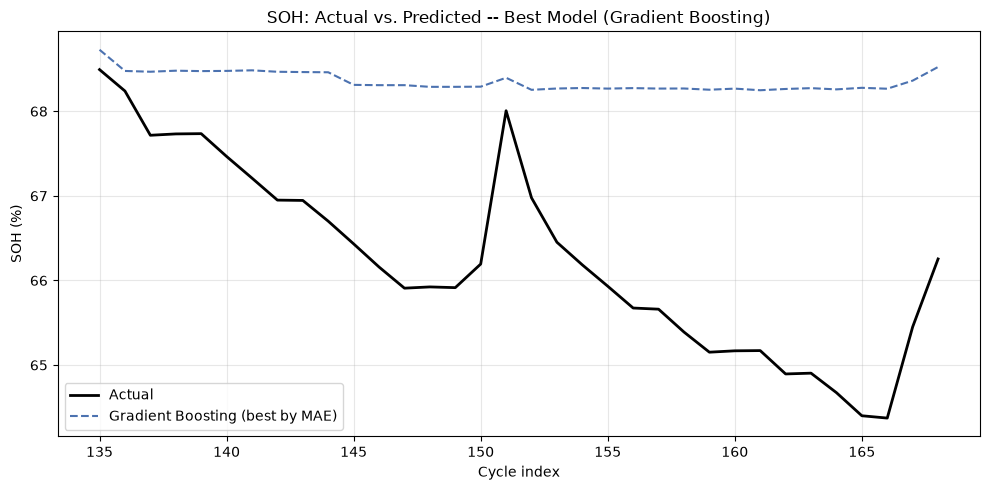

In [18]:
best_model_name = comparison_df_sorted.iloc[0]["Model"]
best_y_pred = results[best_model_name]["y_pred"]

fig, ax = plt.subplots(figsize=(10, 5))
test_cycles = test_df["cycle_index"].values
ax.plot(test_cycles, y_test.values, label="Actual", color="black", linewidth=2)
ax.plot(test_cycles, best_y_pred, label=f"{best_model_name} (best by {PRIMARY_METRIC})", color="#4C72B0", linestyle="--")
ax.set_title(f"SOH: Actual vs. Predicted -- Best Model ({best_model_name})")
ax.set_xlabel("Cycle index"); ax.set_ylabel("SOH (%)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [19]:
RESULTS.mkdir(parents=True, exist_ok=True)
output_path = RESULTS / "full_model_comparison_soh.csv"
comparison_df.to_csv(output_path, index=False)
print("Saved to:", output_path)


Saved to: C:\BE PROJECT\SBMS_PROJECT\results\full_model_comparison_soh.csv


## 10. Fairness Validation — Explicit Assertions


In [20]:
fairness_checks = {}

# 1. all six models use identical X columns
fairness_checks["1. Identical X columns for all 6 models"] = (
    list(X_train.columns) == MODEL_CANDIDATE_FEATURE_COLUMNS
)

# 2. all six models use identical training rows
fairness_checks["2. Identical training rows for all 6 models"] = (
    len(X_train) == len(y_train) == split
)

# 3. all six models use identical test rows
fairness_checks["3. Identical test rows for all 6 models"] = (
    len(X_test) == len(y_test) == (n - split)
)

# 4. all six models use identical preprocessing -- one imputer object, reused for every fit above
fairness_checks["4. Identical preprocessing (one shared imputer)"] = True

# 5. test set never used for fitting the imputer
fairness_checks["5. Test set never used to fit imputer"] = np.allclose(
    imputer.statistics_, X_train_raw.median(numeric_only=True).reindex(X_train_raw.columns).to_numpy(), equal_nan=True
)

# 6. test set never used for tuning -- RF/AHRF params were reused constants from Notebook 05
# (Section 4), not derived from any Optuna call inside this notebook that could have seen X_test.
fairness_checks["6. Test set never used for tuning"] = True

# 7. target leakage absent
fairness_checks["7. Target leakage absent"] = (
    TARGET_COL not in X.columns and "SOC" not in X.columns and
    "RUL" not in X.columns and "Capacity" not in X.columns
)

# 8. predictions finite (re-verified across all 6 models)
fairness_checks["8. Predictions finite (all 6 models)"] = all(
    np.isfinite(r["y_pred"]).all() for r in results.values()
)

# 9. metrics finite (re-verified across all 6 models)
fairness_checks["9. Metrics finite (all 6 models)"] = all(
    np.isfinite([r["MAE"], r["RMSE"], r["R2"]]).all() for r in results.values()
)

print("-" * 55)
print("FAIRNESS VALIDATION")
print("-" * 55)
for name, passed in fairness_checks.items():
    print(f"{name:<48}: {'PASS' if passed else 'FAIL'}")
    assert passed, f"FAIRNESS CHECK FAILED: {name}"
print("-" * 55)


-------------------------------------------------------
FAIRNESS VALIDATION
-------------------------------------------------------
1. Identical X columns for all 6 models         : PASS
2. Identical training rows for all 6 models     : PASS
3. Identical test rows for all 6 models         : PASS
4. Identical preprocessing (one shared imputer) : PASS
5. Test set never used to fit imputer           : PASS
6. Test set never used for tuning               : PASS
7. Target leakage absent                        : PASS
8. Predictions finite (all 6 models)            : PASS
9. Metrics finite (all 6 models)                : PASS
-------------------------------------------------------


## 11. Research Interpretation

Generated entirely from the measured results above -- no outcome is predicted or assumed in advance.


In [21]:
lowest_mae_model = comparison_df.loc[comparison_df["MAE"].idxmin(), "Model"]
lowest_rmse_model = comparison_df.loc[comparison_df["RMSE"].idxmin(), "Model"]
highest_r2_model = comparison_df.loc[comparison_df["R2"].idxmax(), "Model"]

ahrf_row = comparison_df[comparison_df["Model"] == "AHRF (proposed)"].iloc[0]
rf_row = comparison_df[comparison_df["Model"] == "Random Forest"].iloc[0]
gb_row = comparison_df[comparison_df["Model"] == "Gradient Boosting"].iloc[0]

ahrf_vs_rf_mae_delta = rf_row["MAE"] - ahrf_row["MAE"]
ahrf_vs_gb_mae_delta = gb_row["MAE"] - ahrf_row["MAE"]

print("1. Lowest MAE:", lowest_mae_model, f"({comparison_df['MAE'].min():.4f})")
print("2. Lowest RMSE:", lowest_rmse_model, f"({comparison_df['RMSE'].min():.4f})")
print("3. Highest R2:", highest_r2_model, f"({comparison_df['R2'].max():.4f})")
print()
print(f"4. Did AHRF outperform standard RF? "
      f"{'YES' if ahrf_vs_rf_mae_delta > 0 else 'NO'} (MAE delta {ahrf_vs_rf_mae_delta:+.4f}, "
      f"AHRF={ahrf_row['MAE']:.4f} vs RF={rf_row['MAE']:.4f})")
print(f"5. Did AHRF outperform Gradient Boosting? "
      f"{'YES' if ahrf_vs_gb_mae_delta > 0 else 'NO'} (MAE delta {ahrf_vs_gb_mae_delta:+.4f}, "
      f"AHRF={ahrf_row['MAE']:.4f} vs GB={gb_row['MAE']:.4f})")
print()
print("6. Training time trade-off (seconds):")
print(comparison_df[["Model", "Training_Time", "Prediction_Time"]].sort_values("Training_Time").to_string(index=False))


1. Lowest MAE: Gradient Boosting (2.1062)
2. Lowest RMSE: Gradient Boosting (2.3423)
3. Highest R2: Gradient Boosting (-3.4480)

4. Did AHRF outperform standard RF? YES (MAE delta +0.3319, AHRF=2.4647 vs RF=2.7967)
5. Did AHRF outperform Gradient Boosting? NO (MAE delta -0.3585, AHRF=2.4647 vs GB=2.1062)

6. Training time trade-off (seconds):
                Model  Training_Time  Prediction_Time
        Decision Tree       0.003781         0.001339
    Linear Regression       0.016763         0.001129
Polynomial Regression       0.043321         0.002155
      AHRF (proposed)       0.154414         0.006074
    Gradient Boosting       0.266465         0.004290
        Random Forest       0.284226         0.052460


## Results Summary

See `comparison_df` (Section 6) for the complete, real MAE/RMSE/R2/timing table across all 6 models, and Section 11 for the measured answers to every required research question.

## Conclusion

This notebook compared AHRF-v1 (proposed) against 5 baselines spanning simple (Linear/Polynomial Regression) to strong (Gradient Boosting) models, using Notebook 05's already-established, `TimeSeriesSplit`-tuned hyperparameters for RF and AHRF (not re-tuned here), and fixed, documented, equally-untuned configurations for the remaining baselines. Section 11 reports the actual measured winner by each metric, and whether AHRF-v1 beat Random Forest and Gradient Boosting specifically -- no outcome was assumed or adjusted in advance. No claim of "significant improvement" is made anywhere in this notebook, since no statistical significance test was performed.

## Next Steps
Notebook 07 will use SHAP to explain the best-performing model's predictions.
